# Task 4: Fine-Tuning BERT on NLP Classification Task
### Internship Assignment: February 2026 - Data Science - NLP

**Objective:** Build a text classification model by fine-tuning a pre-trained BERT model on the IMDB dataset. Perform experiments with frozen layers and evaluate performance.

## 1. Setup and Installation
Install necessary libraries for transformers and data processing.

In [1]:
!pip install transformers pandas datasets torch scikit-learn matplotlib seaborn

## 2. Data Preprocessing (Mandatory)
Load the IMDB Movie Reviews dataset and handle splitting.

In [2]:
import torch
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Load dataset
dataset = load_dataset("imdb")

# Sample data for faster fine-tuning (optional but recommended for local/Colab free)
train_df = pd.DataFrame(dataset['train']).sample(2000, random_state=42)
test_df = pd.DataFrame(dataset['test']).sample(500, random_state=42)

# Data Splitting: Train, Validation, and Test
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'].tolist(), train_df['label'].tolist(), test_size=0.2, random_state=42
)
test_texts, test_labels = test_df['text'].tolist(), test_df['label'].tolist()

print(f"Train size: {len(train_texts)}, Validation size: {len(val_texts)}, Test size: {len(test_texts)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 1600, Validation size: 400, Test size: 500


## 3. Tokenization
Use `bert-base-uncased` tokenizer to convert text into tokens suitable for BERT.

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_func(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

train_encodings = tokenize_func(train_texts)
val_encodings = tokenize_func(val_texts)
test_encodings = tokenize_func(test_texts)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 4. PyTorch Dataset Creation

In [7]:
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

## 5. Experiment 1: Freeze BERT & Train Classifier
Freeze the BERT layers and only train the classification head.

In [8]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model_exp1 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Freeze all BERT layers
for param in model_exp1.bert.parameters():
    param.requires_grad = False

training_args_exp1 = TrainingArguments(
    output_dir='./results_exp1',
    eval_strategy="epoch",
    per_device_train_batch_size=16,
    num_train_epochs=1,
    learning_rate=2e-5
)

trainer_exp1 = Trainer(
    model=model_exp1,
    args=training_args_exp1,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("Running Experiment 1...")
trainer_exp1.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running Experiment 1...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.698127


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=100, training_loss=0.7020550537109375, metrics={'train_runtime': 904.1844, 'train_samples_per_second': 1.77, 'train_steps_per_second': 0.111, 'total_flos': 105244422144000.0, 'train_loss': 0.7020550537109375, 'epoch': 1.0})

## 6. Experiment 2: Fine-Tuning Last 2 Layers
Freeze all layers except the last 2 encoder blocks of BERT.

In [13]:
model_exp2 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Freeze all initially
for param in model_exp2.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers
for layer in model_exp2.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

training_args_exp2 = TrainingArguments(
    output_dir='./results_exp2',
    eval_strategy="epoch",
    per_device_train_batch_size=16,
    num_train_epochs=1,
    learning_rate=2e-5
)

trainer_exp2 = Trainer(
    model=model_exp2,
    args=training_args_exp2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("Running Experiment 2...")
trainer_exp2.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running Experiment 2...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.625712


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=100, training_loss=0.665612564086914, metrics={'train_runtime': 1135.4667, 'train_samples_per_second': 1.409, 'train_steps_per_second': 0.088, 'total_flos': 105244422144000.0, 'train_loss': 0.665612564086914, 'epoch': 1.0})

## 7. Model Evaluation
Calculate Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_metrics(trainer, dataset):
    preds = trainer.predict(dataset)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    cm = confusion_matrix(y_true, y_pred)

    return {"acc": acc, "precision": precision, "recall": recall, "f1": f1, "cm": cm}

results1 = get_metrics(trainer_exp1, test_dataset)
results2 = get_metrics(trainer_exp2, test_dataset)

print(f"Exp 1 Errors/Metics: {results1['acc']:.4f}, {results1['f1']:.4f}")
print(f"Exp 2 Errors/Metics: {results2['acc']:.4f}, {results2['f1']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Exp 1 Errors/Metics: 0.5020, 0.0743
Exp 2 Errors/Metics: 0.7500, 0.7241


## 8. Analysis & Comparison
Visualization of results.

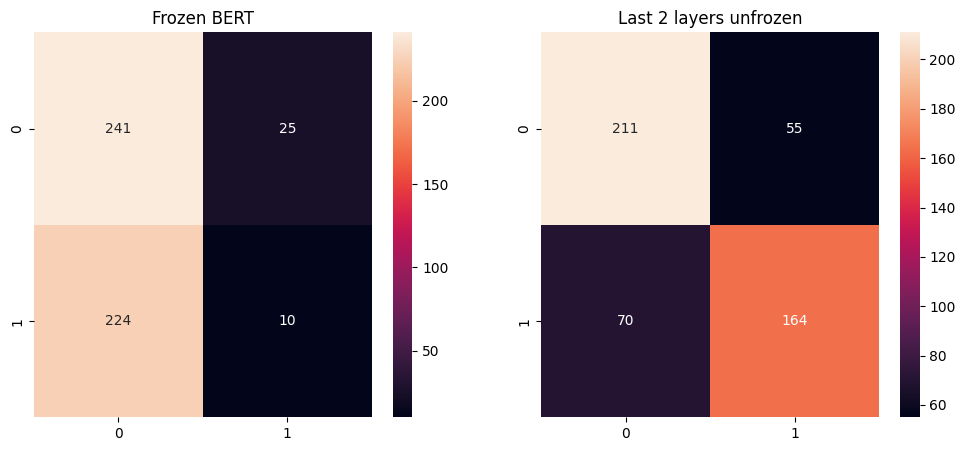

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(results1['cm'], annot=True, fmt='d', ax=ax[0]); ax[0].set_title('Frozen BERT')
sns.heatmap(results2['cm'], annot=True, fmt='d', ax=ax[1]); ax[1].set_title('Last 2 layers unfrozen')
plt.show()